In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


In [3]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

# Data Preprocessing

In [4]:
df = df.drop(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'number_of_reviews', 'last_review', 'reviews_per_month'], axis=1)
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0
1,Brooklyn,40.68769,-73.97490,Private room,99,5,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,1,20


In [5]:
df.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.shape

(27379, 8)

# Checking Outliers

In [8]:
def check_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [9]:
check_outliers(df, 'price')

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
17,Manhattan,40.75403,-73.96714,Entire home/apt,714,28,49,250
35,Manhattan,40.73722,-74.00263,Entire home/apt,1500,3,1,54
42,Manhattan,40.74478,-73.98442,Entire home/apt,349,4,1,255
56,Manhattan,40.76515,-73.98586,Entire home/apt,389,1,1,0
75,Manhattan,40.75000,-73.99637,Entire home/apt,395,3,1,0
...,...,...,...,...,...,...,...,...
27286,Manhattan,40.76955,-73.95988,Entire home/apt,589,6,1,4
27326,Brooklyn,40.65716,-73.97550,Entire home/apt,450,4,2,87
27331,Manhattan,40.71895,-73.99793,Entire home/apt,5250,1,1,0
27355,Manhattan,40.74775,-73.99167,Entire home/apt,999,2,1,0


In [10]:
print(df['room_type'].unique())

['Private room' 'Entire home/apt' 'Shared room']


In [11]:
print(df['neighbourhood_group'].unique())

['Brooklyn' 'Queens' 'Manhattan' 'Bronx' 'Staten Island']


# LabelEncoding categorical col into numerical data

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['neighbourhood_group'] = le.fit_transform(df['neighbourhood_group'])
df['room_type'] = le.fit_transform(df['room_type'])

df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,1,40.69591,-73.96284,1,58,2,1,0
1,1,40.68769,-73.97490,1,99,5,1,250
2,1,40.67667,-73.91750,0,180,2,1,74
3,3,40.74340,-73.90588,0,50,1,2,0
4,1,40.66600,-73.99020,0,210,4,1,20


## splitting of data into train, test and safe 

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_safe, y_train, y_safe = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## scaling the data

In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = regressor.predict(X_test)
y_pred

array([210.6844566 ,  51.15298343, 101.60682415, ..., 197.74822245,
       262.05795566, 261.34864079])

In [20]:
from sklearn.metrics import r2_score

print('R2 Score:', r2_score(y_test, y_pred))

R2 Score: 0.14161210720671658


In [21]:
print('Accuracy of linear regression classifier on test set: {:.2f}'.format(100*(regressor.score(X_test, y_test))))

Accuracy of linear regression classifier on test set: 14.16


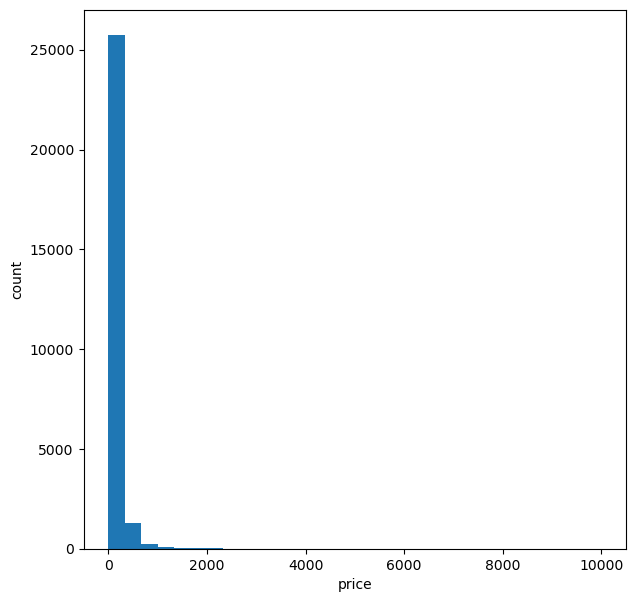

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.hist(df['price'], bins=30)
plt.xlabel('price')
plt.ylabel('count')
plt.show()

<Axes: xlabel='minimum_nights', ylabel='price'>

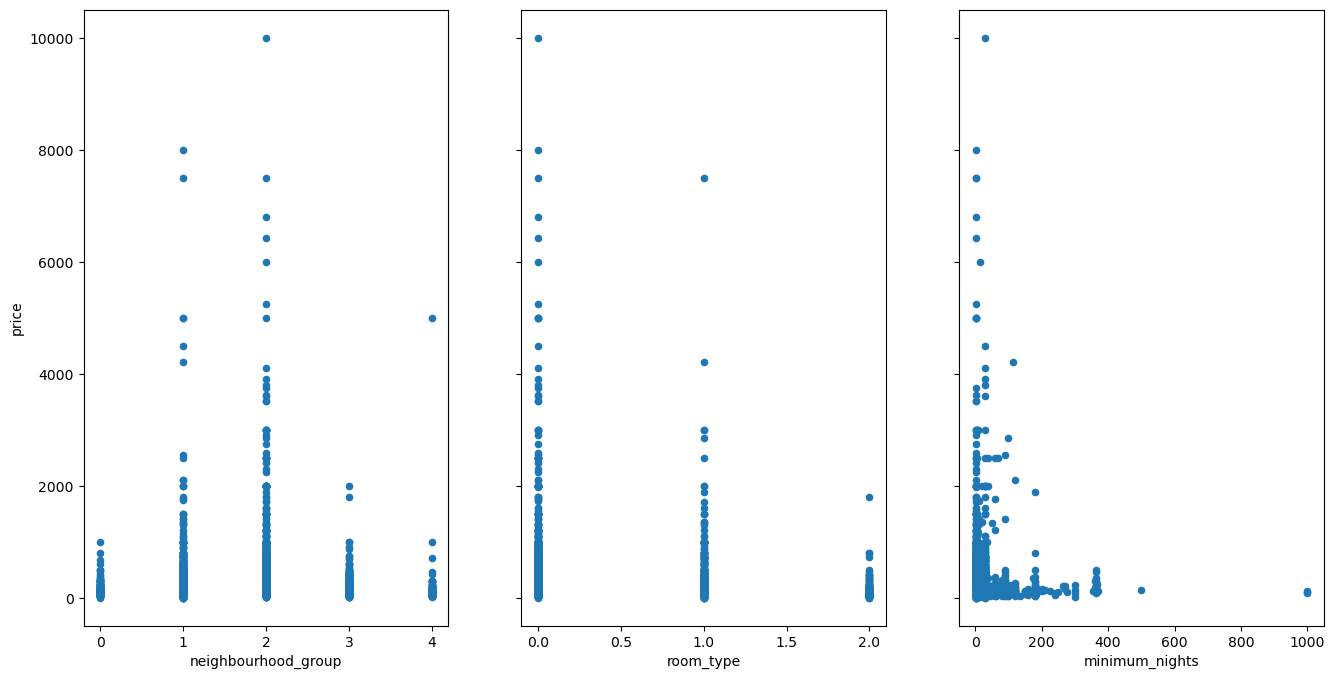

In [27]:
# visualize the relationship between the features and the response using scatterplots
fig, axs = plt.subplots(1, 3, sharey=True)
df.plot(kind='scatter', x='neighbourhood_group', y='price', ax=axs[0], figsize=(16, 8))
df.plot(kind='scatter', x='room_type', y='price', ax=axs[1])
df.plot(kind='scatter', x='minimum_nights', y='price', ax=axs[2])

In [28]:
df.describe()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
count,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000
mean,1.675993,40.728836,-73.952071,0.502721,151.569561,7.056722,7.228788,113.430293
std,0.735011,0.054629,0.046278,0.544685,219.807784,20.194945,33.173634,132.039807
min,0.000000,40.506410,-74.242850,0.000000,0.000000,1.000000,1.000000,0.000000
25%,1.000000,40.689955,-73.983080,0.000000,69.000000,1.000000,1.000000,0.000000
50%,2.000000,40.723030,-73.955700,0.000000,105.000000,3.000000,1.000000,45.000000
75%,2.000000,40.763045,-73.935830,1.000000,175.000000,5.000000,2.000000,230.000000
max,4.000000,40.913060,-73.717950,2.000000,10000.000000,999.000000,327.000000,365.000000
